In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
df=pd.read_csv('Churn_Modelling.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [17]:
print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))


Correlation Matrix:
                   CreditScore    Gender       Age    Tenure   Balance  \
CreditScore           1.000000 -0.002857 -0.003965  0.000842  0.006268   
Gender               -0.002857  1.000000 -0.027544  0.014733  0.012087   
Age                  -0.003965 -0.027544  1.000000 -0.009997  0.028308   
Tenure                0.000842  0.014733 -0.009997  1.000000 -0.012254   
Balance               0.006268  0.012087  0.028308 -0.012254  1.000000   
NumOfProducts         0.012238 -0.021859 -0.030680  0.013444 -0.304180   
HasCrCard            -0.005458  0.005766 -0.011721  0.022583 -0.014858   
IsActiveMember        0.025651  0.022544  0.085472 -0.028362 -0.010084   
EstimatedSalary      -0.001384 -0.008112 -0.007201  0.007784  0.012797   
Exited               -0.027094 -0.106512  0.285323 -0.014001  0.118533   
Geography_Germany     0.005538 -0.024628  0.046897 -0.000567  0.401110   
Geography_Spain       0.004780  0.016889 -0.001685  0.003868 -0.134892   

                

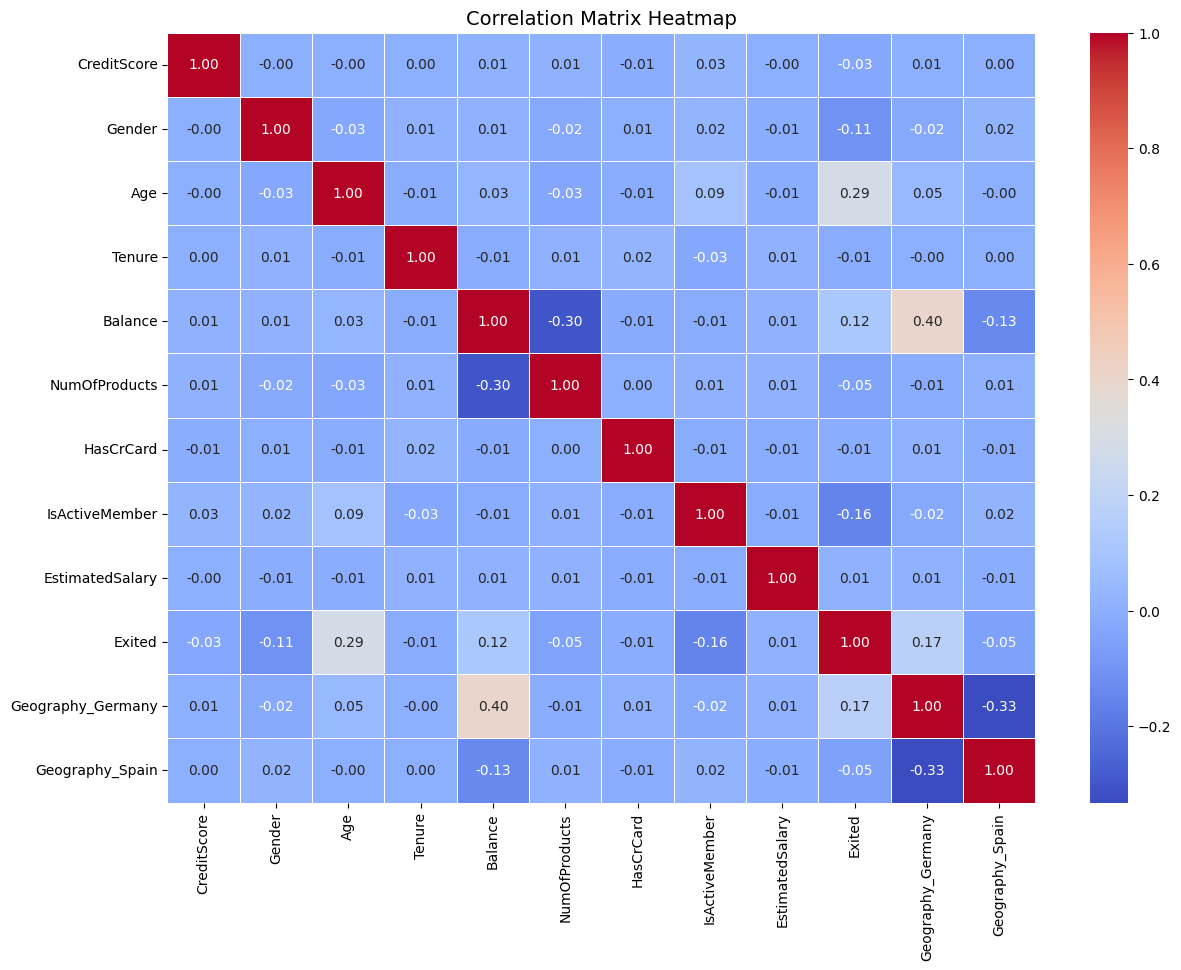

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

# Correlation calculation
corr_matrix = df.corr(numeric_only=True)

# Heatmap with values shown
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.show()

In [4]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

In [5]:
le_gender = LabelEncoder()
df["Gender"] = le_gender.fit_transform(df["Gender"])

In [6]:
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

In [7]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [10]:
model = keras.Sequential()


In [11]:
model.add(layers.Dense(units=16, activation='relu', input_dim=X_train.shape[1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.add(layers.Dense(units=8, activation='relu'))

In [13]:
model.add(layers.Dense(units=1, activation='sigmoid'))

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.2
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7277 - loss: 0.5806 - val_accuracy: 0.7987 - val_loss: 0.4595
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7987 - loss: 0.4545 - val_accuracy: 0.8075 - val_loss: 0.4253
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8018 - loss: 0.4403 - val_accuracy: 0.8263 - val_loss: 0.4119
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8247 - loss: 0.4117 - val_accuracy: 0.8369 - val_loss: 0.4035
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8215 - loss: 0.4160 - val_accuracy: 0.8419 - val_loss: 0.3946
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8343 - loss: 0.4039 - val_accuracy: 0.8469 - val_loss: 0.3847
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8450 - loss: 0.3845 - val_accuracy: 0.8475 - val_loss: 0.3746
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8507 - loss: 0.3750 - val_accu

In [18]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [19]:
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nAccuracy Score:")
print(acc)


Confusion Matrix:
[[1536   71]
 [ 215  178]]

Accuracy Score:
0.857
